In [5]:
%pip install matplotlib pandas seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
!mkdir -p fonts
!wget -q https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf \
    -O fonts/NanumGothic.ttf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # 음수 부호 깨짐 방지

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

rng = np.random.default_rng(13)

N = 150
genre = rng.choice(['뉴스', '소설', '대화', '학술'], size=N, p=[0.3, 0.3, 0.2, 0.2])
base = {'뉴스': 22, '소설': 18, '대화': 9, '학술': 28}

words = (np.array([base[g] for g in genre]) + rng.normal(0, 5, N)).clip(3, 60)
words = words.round().astype(int)

syllables = (words * 2.5 + rng.normal(0, 4, N)).clip(5, None).round().astype(int)
read_time = (syllables * 0.35 + rng.normal(0, 1.5, N)).clip(1, None).round(1)
difficulty = (words * 0.15 + rng.normal(0, 1.2, N)).clip(1, 10).round(1)

texts = pd.DataFrame({
    '장르': genre,
    '어절수': words,
    '음절수': syllables,
    '읽기시간': read_time,
    '난이도': difficulty,
})

trends = pd.DataFrame({
    '연도': [1990, 1995, 2000, 2005, 2010, 2015, 2020],
    '뉴스': [5.1, 6.3, 8.0, 9.4, 11.2, 13.5, 15.1],
    '소설': [3.2, 3.5, 4.0, 4.6, 5.1, 5.8, 6.4],
})

문항 Q1에 대한 설명
texts['장르'].value_counts()로 장르별 빈도를 구한 뒤 ax.bar()를 사용해 y축이 0부터 시작하는 막대 그래프를 그렸습니다. 또한 ax.hist()와 ax.scatter()를 활용해 각각 어절 수 분포와 음절수-읽기시간 산점도를 구현했으며, 모든 그래프는 객체지향 방식(fig, ax = plt.subplots())을 준수하여 작성했습니다.

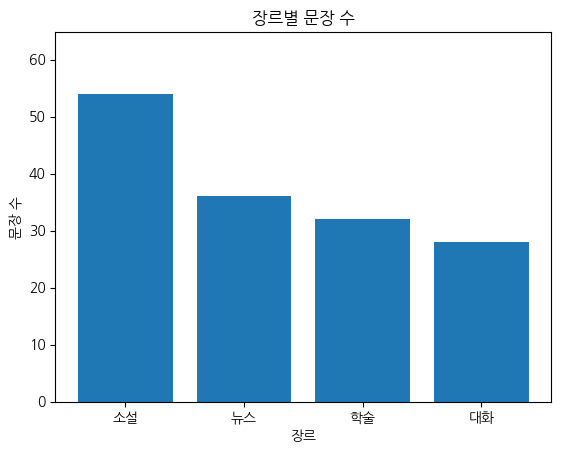

In [8]:
def plot_genre_counts() -> None:
    genre_counts = texts['장르'].value_counts()
    fig, ax = plt.subplots()
    ax.bar(genre_counts.index, genre_counts.values)
    ax.set_ylim(0, genre_counts.max() * 1.2) 
    ax.set_title('장르별 문장 수')
    ax.set_xlabel('장르')
    ax.set_ylabel('문장 수')
    plt.show()

plot_genre_counts()

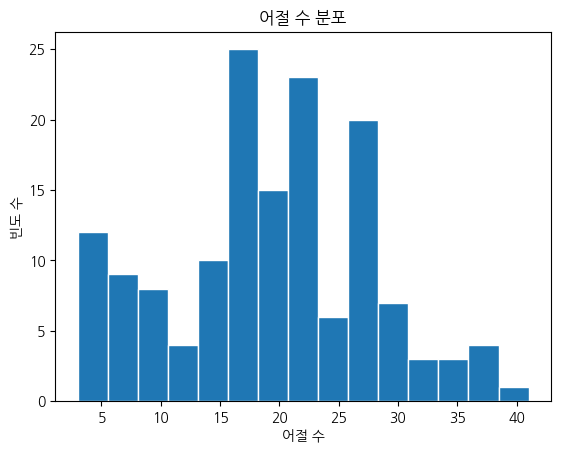

In [9]:
def plot_words_hist() -> None:
    fig, ax = plt.subplots()
    ax.hist(texts['어절수'], bins=15, edgecolor='white')
    ax.set_title('어절 수 분포')
    ax.set_xlabel('어절 수')
    ax.set_ylabel('빈도 수')
    plt.show()

plot_words_hist()

어절 수는 주로 15~25 구간에 가장 많이 몰려 있습니다.

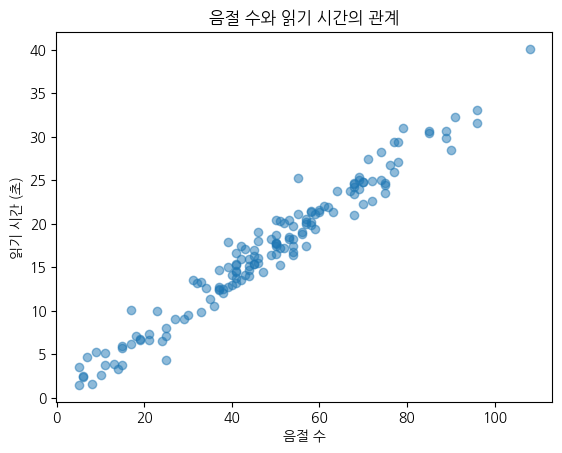

In [10]:
def plot_syllables_vs_time() -> None:
    fig, ax = plt.subplots()
    ax.scatter(texts['음절수'], texts['읽기시간'], alpha=0.5)
    ax.set_title('음절 수와 읽기 시간의 관계')
    ax.set_xlabel('음절 수')
    ax.set_ylabel('읽기 시간 (초)')
    plt.show()

plot_syllables_vs_time()

음절 수가 증가할수록 읽기 시간도 비례하여 증가하는 뚜렷한 우상향 관계를 보입니다.

문항 Q2에 대한 설명:
ax.plot()을 통해 연도별 외래어 비율 추이를 마커와 범례가 포함된 선 그래프로 시각화했습니다. 이후 plt.subplots(2, 2)로 생성한 2x2 서브플롯 격자에 앞서 구현한 4개의 그래프를 각각 배치하고, fig.tight_layout()으로 간격을 조정한 뒤 savefig()를 이용해 PNG 파일로 저장했습니다.

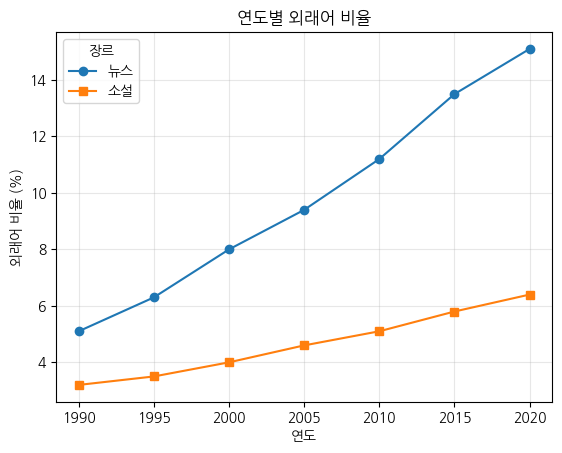

In [11]:
def plot_trends() -> None:
    fig, ax = plt.subplots()
    ax.plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
    ax.plot(trends['연도'], trends['소설'], marker='s', label='소설')
    ax.legend(title='장르')
    ax.grid(True, alpha=0.3)
    ax.set_title('연도별 외래어 비율')
    ax.set_xlabel('연도')
    ax.set_ylabel('외래어 비율 (%)')
    plt.show()

plot_trends()

두 장르 모두 시간이 지남에 따라 외래어 비율이 증가하고 있으며, 특히 뉴스의 증가 폭이 소설보다 훨씬 가파릅니다.

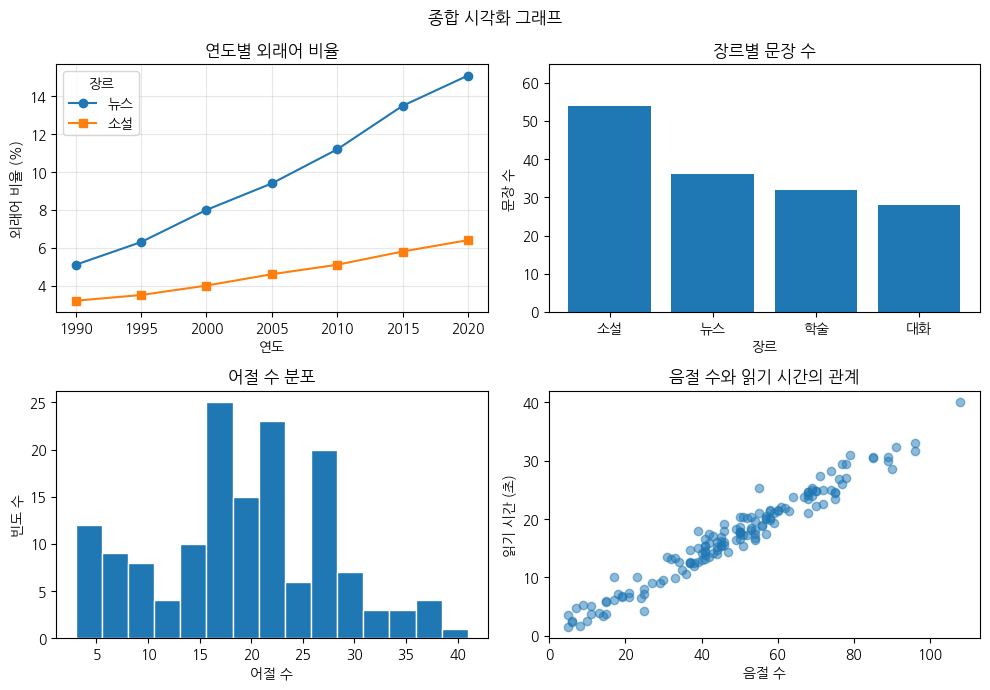

In [12]:
def plot_subplots() -> None:
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))

    # axes[0, 0]: Q2(a)
    axes[0, 0].plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
    axes[0, 0].plot(trends['연도'], trends['소설'], marker='s', label='소설')
    axes[0, 0].legend(title='장르')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_title('연도별 외래어 비율')
    axes[0, 0].set_xlabel('연도')
    axes[0, 0].set_ylabel('외래어 비율 (%)')

    # axes[0, 1]: Q1(a)
    genre_counts = texts['장르'].value_counts()
    axes[0, 1].bar(genre_counts.index, genre_counts.values)
    axes[0, 1].set_ylim(0, genre_counts.max() * 1.2)
    axes[0, 1].set_title('장르별 문장 수')
    axes[0, 1].set_xlabel('장르')
    axes[0, 1].set_ylabel('문장 수')

    # axes[1, 0]: Q1(b)
    axes[1, 0].hist(texts['어절수'], bins=15, edgecolor='white')
    axes[1, 0].set_title('어절 수 분포')
    axes[1, 0].set_xlabel('어절 수')
    axes[1, 0].set_ylabel('빈도 수')

    # axes[1, 1]: Q1(c)
    axes[1, 1].scatter(texts['음절수'], texts['읽기시간'], alpha=0.5)
    axes[1, 1].set_title('음절 수와 읽기 시간의 관계')
    axes[1, 1].set_xlabel('음절 수')
    axes[1, 1].set_ylabel('읽기 시간 (초)')

    fig.suptitle('종합 시각화 그래프')
    fig.tight_layout()
    fig.savefig('hw13_subplots.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_subplots()

문항 Q3에 대한 설명
Seaborn 라이브러리를 활용하여 sns.scatterplot의 hue 파라미터로 장르별 색상을 구분하고, sns.boxplot으로 난이도 분포를 시각화했습니다. 마지막으로 texts.corr() 메서드로 숫자형 변수 간의 상관계수 행렬을 구한 뒤, sns.heatmap의 annot=True 속성을 사용해 상관관계를 수치와 색상으로 표현했습니다.

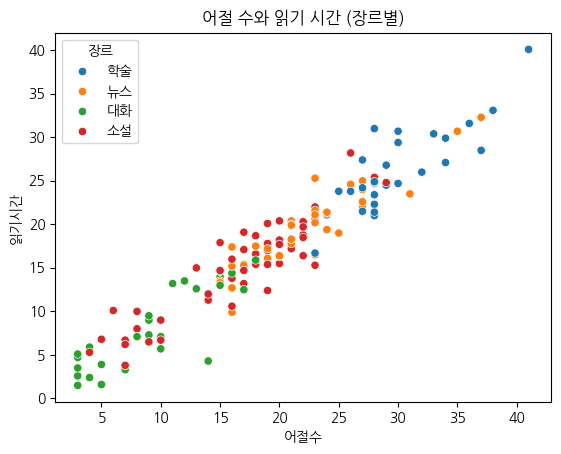

In [13]:
def plot_sns_scatter() -> None:
    fig, ax = plt.subplots()
    sns.scatterplot(x='어절수', y='읽기시간', hue='장르', data=texts, ax=ax)
    ax.set_title('어절 수와 읽기 시간 (장르별)')
    plt.show()

plot_sns_scatter()

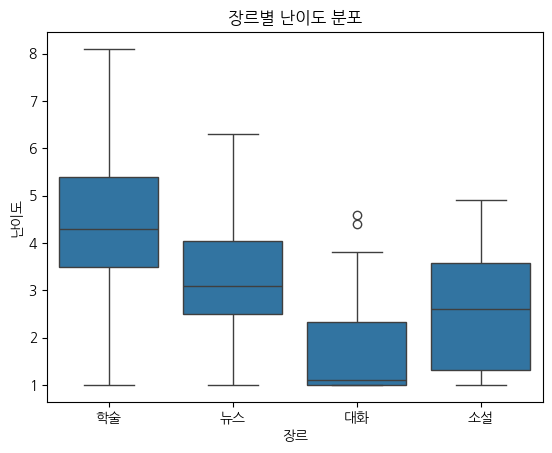

In [14]:
def plot_sns_box() -> None:
    fig, ax = plt.subplots()
    sns.boxplot(x='장르', y='난이도', data=texts, ax=ax)
    ax.set_title('장르별 난이도 분포')
    plt.show()

plot_sns_box()

가장 난이도가 높은 장르는 '학술'이며, 퍼짐(상자의 크기)이 가장 큰 장르 또한 '학술'입니다.

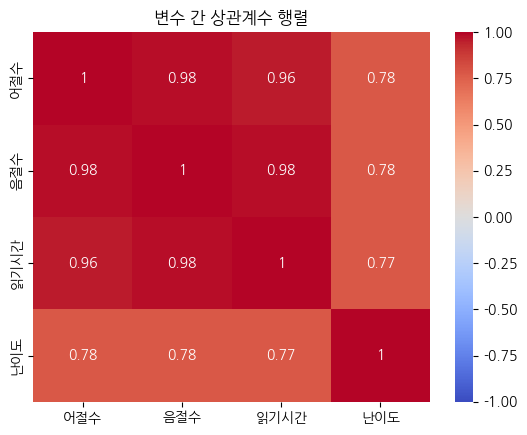

In [15]:
def plot_sns_heatmap() -> None:
    fig, ax = plt.subplots()
    corr_matrix = texts[['어절수', '음절수', '읽기시간', '난이도']].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
    ax.set_title('변수 간 상관계수 행렬')
    plt.show()

plot_sns_heatmap()

어절 수와 음절 수(또는 음절 수와 읽기 시간)가 가장 강한 양의 상관관계를 보입니다.이는 문장의 어절이 많아질수록 당연히 구성하는 음절이 많아지고, 읽어야 할 글자(음절)가 많아지면 읽는 시간도 비례하여 늘어나기 때문입니다.

문항 Q4에 대한 설명:
lt.subplots(1, 2)를 사용해 서브플롯을 생성한 뒤, 4(a)에서는 sns.barplot과 sns.boxplot을 나란히 배치하여 막대 그래프(평균)와 상자 그림(분포)의 시각적 정보량 차이를 구현했습니다. 4(b)에서는 groupby로 장르별 평균 어절 수를 구한 뒤 ax.bar로 시각화하되, set_ylim을 이용해 y축 시작점을 각각 15와 0으로 다르게 설정하여 축 범위 왜곡에 따른 착시 효과를 비교했습니다.

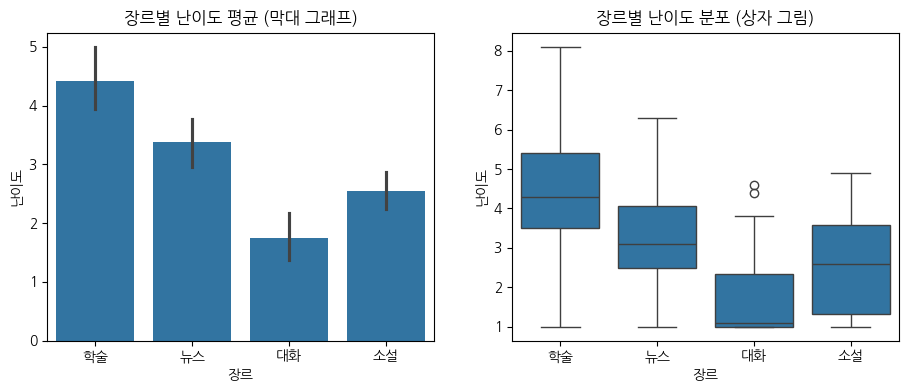

In [16]:
def plot_bar_vs_box() -> None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sns.barplot(x='장르', y='난이도', data=texts, ax=axes[0])
    axes[0].set_title('장르별 난이도 평균 (막대 그래프)')

    sns.boxplot(x='장르', y='난이도', data=texts, ax=axes[1])
    axes[1].set_title('장르별 난이도 분포 (상자 그림)')

    plt.show()

plot_bar_vs_box()

왼쪽 막대 그래프는 데이터의 단순 '평균'만을 보여주기 때문에, 실제 난이도 데이터가 얼마나 넓게 퍼져 있는지(분산, 극단치 등)의 분포 정보를 숨깁니다.두 장르의 평균 난이도가 비슷하게 나타나더라도, 상자 그림을 보면 실제로는 특정 장르가 훨씬 더 넓은 난이도 범위를 가지거나 이상치가 존재할 수 있음을 확인할 수 있습니다.

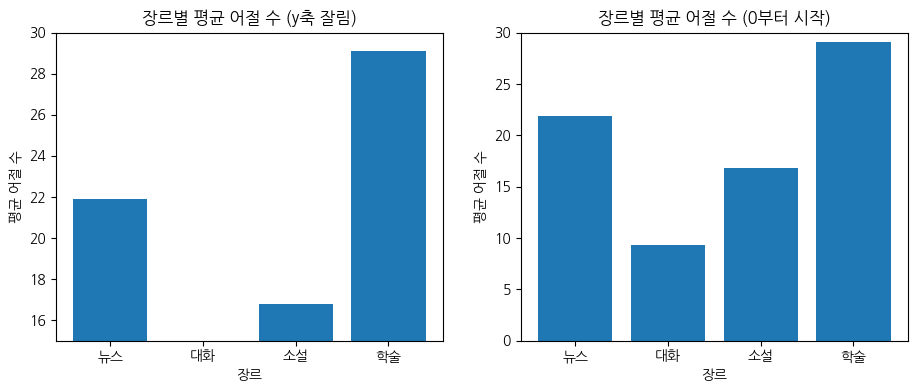

In [17]:
def plot_axis_trap() -> None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    mean_words = texts.groupby('장르')['어절수'].mean()

    axes[0].bar(mean_words.index, mean_words.values)
    axes[0].set_ylim(15, 30)
    axes[0].set_title('장르별 평균 어절 수 (y축 잘림)')
    axes[0].set_xlabel('장르')
    axes[0].set_ylabel('평균 어절 수')

    axes[1].bar(mean_words.index, mean_words.values)
    axes[1].set_ylim(0, 30)
    axes[1].set_title('장르별 평균 어절 수 (0부터 시작)')
    axes[1].set_xlabel('장르')
    axes[1].set_ylabel('평균 어절 수')

    plt.show()

plot_axis_trap()

축을 15부터 시작한 왼쪽 그래프는 장르 간의 어절 수 차이가 시각적으로 매우 과장되어 보입니다.막대의 길이는 데이터 값의 크기를 직접적으로 나타내므로, 비율이 왜곡되지 않도록 막대 그래프의 y축은 반드시 0부터 시작해야 정직하게 데이터의 크기를 비교할 수 있습니다.